# Adaptive Sampling


This notebook aims to reduce the number of samples required to train an accurate surrogate model. One approach is to use adaptive sampling, which explores the design space in under-sampled parts of the design space while exploiting the knowledge gained from already finished simulation runs (exploration). 

This notebook is an example of the use of Lola-Voronoi based sampling. It is applicable in connection with any surrogate model type. Here it is applied with a Gaussian Process model. [[1]]

[1]: https://ieeexplore.ieee.org/abstract/document/5429687/

<img src="image/LOLA-Voronoi.jpg">

In [1]:
from besos import eppy_funcs as ef
import sampling
import numpy as np
import pandas as pd

from problem import EPProblem
from evaluator import EvaluatorEP

from sklearn.gaussian_process.kernels import (RBF, Matern, RationalQuadratic, ExpSineSquared, DotProduct,
                                              ConstantKernel)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

from sampling import adaptive_sampler_lv
from parameter_sets import parameter_set

## Define sampler settings

In [2]:
n_param = 7 # or 7 or 11
n_samples_init = 20 # initial set of samples collected using common low-discrepancy sampling
no_iter = 5 # number of iterations the sampler runs
n = 4 # number of samples added per iteration of the adaptive sampler

## Set up parameters, objectives to set up a problem and an E+ evaluator instance.

For more details on that part check out other notebooks in the Example folder.

In [3]:
parameters = parameter_set(n_param)
parameters
problem = EPProblem(parameters, ['Electricity:Facility'])
building = ef.get_building(mode='idf')
inputs = sampling.dist_sampler(sampling.lhs, problem, n_samples_init)
evaluator = EvaluatorEP(problem, building)
outputs = evaluator.df_apply(inputs)

/opt/conda/envs/design/lib/python3.9/site-packages/besos/parameters.py:424: FutureWarning: Use value_descriptors instead of value_descriptor.
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/besos/problem.py:150: RuntimeWarning: Duplicate names found. (duplicate, repetitions): [('RangeParameter [10, 15]', 2)]
Attempting to fix automatically
  warnings.warn(


Executing:   0%|          | 0/20 [00:00<?, ?row/s]

EnergyPlus Starting
EnergyPlus, Version 9.0.1-bb7ca4f0da, YMD=2024.11.19 13:34
Initializing Response Factors
Calculating CTFs for "MASS NON-RES EXT WALL", Construction # 1
Calculating CTFs for "ATTIC NON-RES FLOOR", Construction # 2
Calculating CTFs for "ATTIC NON-RES ROOF", Construction # 3
Calculating CTFs for "EXT-SLAB", Construction # 4
Calculating CTFs for "INT-WALLS", Construction # 5
Calculating CTFs for "INTERIORFURNISHINGS", Construction # 7
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone Report Variables
Initializing Surface (Shading) Report Variables
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior D

EnergyPlus Completed Successfully.


EnergyPlus Starting
EnergyPlus, Version 9.0.1-bb7ca4f0da, YMD=2024.11.19 13:34
Initializing Response Factors
Calculating CTFs for "MASS NON-RES EXT WALL", Construction # 1
Calculating CTFs for "ATTIC NON-RES FLOOR", Construction # 2
Calculating CTFs for "ATTIC NON-RES ROOF", Construction # 3
Calculating CTFs for "EXT-SLAB", Construction # 4
Calculating CTFs for "INT-WALLS", Construction # 5
Calculating CTFs for "INTERIORFURNISHINGS", Construction # 7
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone Report Variables
Initializing Surface (Shading) Report Variables
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior D

...

EnergyPlus Completed Successfully.


EnergyPlus Starting
EnergyPlus, Version 9.0.1-bb7ca4f0da, YMD=2024.11.19 13:34
Initializing Response Factors
Calculating CTFs for "MASS NON-RES EXT WALL", Construction # 1
Calculating CTFs for "ATTIC NON-RES FLOOR", Construction # 2
Calculating CTFs for "ATTIC NON-RES ROOF", Construction # 3
Calculating CTFs for "EXT-SLAB", Construction # 4
Calculating CTFs for "INT-WALLS", Construction # 5
Calculating CTFs for "INTERIORFURNISHINGS", Construction # 7
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone Report Variables
Initializing Surface (Shading) Report Variables
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior D

EnergyPlus Completed Successfully.


EnergyPlus Starting
EnergyPlus, Version 9.0.1-bb7ca4f0da, YMD=2024.11.19 13:34
Initializing Response Factors
Calculating CTFs for "MASS NON-RES EXT WALL", Construction # 1
Calculating CTFs for "ATTIC NON-RES FLOOR", Construction # 2
Calculating CTFs for "ATTIC NON-RES FLOOR", Construction # 2
Calculating CTFs for "ATTIC NON-RES ROOF", Construction # 3
Calculating CTFs for "EXT-SLAB", Construction # 4
Calculating CTFs for "INT-WALLS", Construction # 5
Calculating CTFs for "INTERIORFURNISHINGS", Construction # 7
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone Report Variables
Initializing Surface (Shading) Report Variables
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shadi

EnergyPlus Completed Successfully.


## Initial training of Surrogate Model
Here we use a Gaussian Process surrogate model. Feel free to check out the $\textit{Fit GP model}$ notebook for more details.

In [4]:
parameters

[Parameter(selector=FieldSelector(field_name='Conductivity', object_name='Mass NonRes Wall Insulation'), value_descriptors=[RangeParameter(name='Conductivity', min=0.02, max=0.2)]),
 Parameter(selector=FieldSelector(field_name='Thickness', object_name='AtticFloor NonRes Insulation'), value_descriptors=[RangeParameter(name='Thickness', min=0.1, max=0.3)]),
 Parameter(selector=FieldSelector(field_name='U-Factor', object_name='NonRes Fixed Assembly Window'), value_descriptors=[RangeParameter(name='U-Factor', min=0.1, max=5)]),
 Parameter(selector=FieldSelector(field_name='Solar Heat Gain Coefficient', object_name='NonRes Fixed Assembly Window'), value_descriptors=[RangeParameter(name='Solar Heat Gain Coefficient', min=0.01, max=0.99)]),
 Parameter(selector=FieldSelector(field_name='Watts per Zone Floor Area', class_name='ElectricEquipment', object_name='*'), value_descriptors=[RangeParameter(min=10, max=15)]),
 Parameter(selector=FieldSelector(field_name='Watts per Zone Floor Area', class

In [5]:
train_in, test_in, train_out, test_out = train_test_split(inputs, outputs, test_size=0.2)

In [6]:
inputs

,Conductivity,Thickness,U-Factor,Solar Heat Gain Coefficient,"RangeParameter [10, 15]","RangeParameter [10, 15]_1",Window to Wall Ratio
0,0.044413,0.137947,2.975507,0.068024,11.750517,10.908725,0.402263
1,0.163747,0.189909,2.090367,0.836426,11.686181,11.767864,0.681053
2,0.089761,0.299660,4.658476,0.566131,14.608640,13.687231,0.499278
3,0.122937,0.203964,3.105514,0.352939,11.062534,14.721521,0.010048
4,0.027015,0.167315,1.735301,0.930745,10.698403,13.889351,0.818268
5,0.176859,0.220093,2.446538,0.215414,13.925164,12.756427,0.332875
6,0.132802,0.256897,0.605807,0.693916,13.025746,14.114462,0.846543
7,0.104709,0.230487,3.896103,0.765283,13.324755,11.258623,0.200977
8,0.197923,0.128154,1.277852,0.717006,12.737129,12.320824,0.627883
9,0.032545,0.173157,3.445838,0.426090,12.362905,10.455167,0.575529


In [7]:
hyperparameters = {'kernel':[None,1.0 * RBF(length_scale=1.0, length_scale_bounds=(1e-1, 10.0)),
                             1.0 * RationalQuadratic(length_scale=1.0, alpha=0.5),
                             #ConstantKernel(0.1, (0.01, 10.0))*(DotProduct(sigma_0=1.0, sigma_0_bounds=(0.1, 10.0))**2),
                             1.0 * Matern(length_scale=1.0, length_scale_bounds=(1e-1, 10.0)),]}

folds = 3

gp = GaussianProcessRegressor(normalize_y=True)

clf = GridSearchCV(gp, hyperparameters, cv=folds)
clf.fit(train_in, train_out)

print(f'The best performing model $R^2$ score on the validation set: {clf.best_score_}')
print(f'The model $R^2$ parameters: {clf.best_params_}')
print(f'The best performing model $R^2$ score on a separate test set: {clf.best_estimator_.score(test_in, test_out)}')
reg = clf.best_estimator_

The best performing model $R^2$ score on the validation set: 0.9854894243129366
The model $R^2$ parameters: {'kernel': 1**2 * RBF(length_scale=1)}
The best performing model $R^2$ score on a separate test set: 0.7491442068780095


/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:616: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:616: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_opti

# LOLA - Voronoi sampling
Here we run our implementation of LOLA-Voronoi sampling. New building designs to be simulated are picked around already simulated building design with a high hybrid score $H$.

$H = V + E$ 

$H$ is used to incentives exploration $V$ and exploitation $E$. $V$ is the Voronoi cell size to approximate the sample density and $E$ the local-linear estimate to approximate the gradient in the neighbourhood of a sample.

In [8]:
AS = adaptive_sampler_lv(train_in.values, train_out.values, n, problem, evaluator, reg, test_in, test_out, verbose = False)
AS.run(no_iter)

/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but GaussianProcessRegressor was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but GaussianProcessRegressor was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but GaussianProcessRegressor was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but GaussianProcessRegressor was fitted with feature names
  warnings.warn(
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but GaussianProcessRegressor was fitted with feature names
  warnings.warn(
/opt/conda

Executing:   0%|          | 0/4 [00:00<?, ?row/s]

EnergyPlus Starting
EnergyPlus, Version 9.0.1-bb7ca4f0da, YMD=2024.11.19 13:34
Initializing Response Factors
Calculating CTFs for "MASS NON-RES EXT WALL", Construction # 1
Calculating CTFs for "ATTIC NON-RES FLOOR", Construction # 2
Calculating CTFs for "ATTIC NON-RES ROOF", Construction # 3
Calculating CTFs for "EXT-SLAB", Construction # 4
Calculating CTFs for "INT-WALLS", Construction # 5
Calculating CTFs for "INTERIORFURNISHINGS", Construction # 7
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone Report Variables
Initializing Surface (Shading) Report Variables
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior D

EnergyPlus Completed Successfully.


EnergyPlus Starting
EnergyPlus, Version 9.0.1-bb7ca4f0da, YMD=2024.11.19 13:34
Initializing Response Factors
Calculating CTFs for "MASS NON-RES EXT WALL", Construction # 1
Calculating CTFs for "ATTIC NON-RES FLOOR", Construction # 2
Calculating CTFs for "ATTIC NON-RES ROOF", Construction # 3
Calculating CTFs for "EXT-SLAB", Construction # 4
Calculating CTFs for "INT-WALLS", Construction # 5
Calculating CTFs for "INTERIORFURNISHINGS", Construction # 7
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone Report Variables
Initializing Surface (Shading) Report Variables
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior D

...

EnergyPlus Completed Successfully.


EnergyPlus Starting
EnergyPlus, Version 9.0.1-bb7ca4f0da, YMD=2024.11.19 13:36
Initializing Response Factors
Calculating CTFs for "MASS NON-RES EXT WALL", Construction # 1
Calculating CTFs for "ATTIC NON-RES FLOOR", Construction # 2
Calculating CTFs for "ATTIC NON-RES ROOF", Construction # 3
Calculating CTFs for "EXT-SLAB", Construction # 4
Calculating CTFs for "INT-WALLS", Construction # 5
Calculating CTFs for "INTERIORFURNISHINGS", Construction # 7
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone Report Variables
Initializing Surface (Shading) Report Variables
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior D

EnergyPlus Completed Successfully.


EnergyPlus Starting
EnergyPlus, Version 9.0.1-bb7ca4f0da, YMD=2024.11.19 13:36
Initializing Response Factors
Calculating CTFs for "MASS NON-RES EXT WALL", Construction # 1
Calculating CTFs for "ATTIC NON-RES FLOOR", Construction # 2
Calculating CTFs for "ATTIC NON-RES ROOF", Construction # 3
Calculating CTFs for "EXT-SLAB", Construction # 4
Calculating CTFs for "INT-WALLS", Construction # 5
Calculating CTFs for "INTERIORFURNISHINGS", Construction # 7
Initializing Window Optical Properties
Initializing Solar Calculations
Allocate Solar Module Arrays
Initializing Zone Report Variables
Initializing Surface (Shading) Report Variables
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior D

EnergyPlus Completed Successfully.
/opt/conda/envs/design/lib/python3.9/site-packages/sklearn/base.py:443: UserWarning: X has feature names, but GaussianProcessRegressor was fitted without feature names
  warnings.warn(


## Visualization
We visualize the working scheme of the adaptive sampler by reducing the input dimensionality to 2 using multi-dimensional scaling. 

Text(0.5, 0, 'No. of samples')

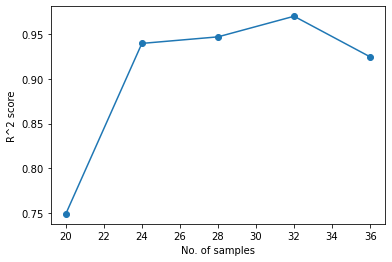

In [9]:
plt.plot(range(n_samples_init, n_samples_init + no_iter*n,n), AS.score[:-1],'-o')
plt.ylabel('R^2 score')
plt.xlabel('No. of samples')

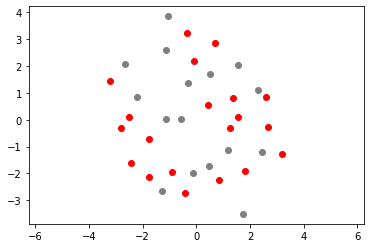

In [10]:
# Manifold model
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler

scaler_mds = StandardScaler()
p_norm = scaler_mds.fit_transform(AS.P)

model = MDS(n_components=2, random_state=1)
out3 = model.fit_transform(p_norm)


plt.scatter(out3[:len(train_in), 0], out3[:len(train_in), 1], color='grey')
plt.scatter(out3[len(train_in):, 0], out3[len(train_in):, 1], color='r')
plt.axis('equal');

The density plot shows where the density of samples is high. Those areas may indicate more complex parts in the design space.

/opt/conda/envs/design/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


(-4.0, 4.0)

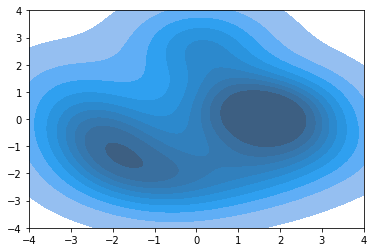

In [11]:
import seaborn as sns
ax = sns.kdeplot(out3[len(train_in):,0], out3[len(train_in):,1], shade=True)
plt.ylim([-4,4])
plt.xlim([-4,4])

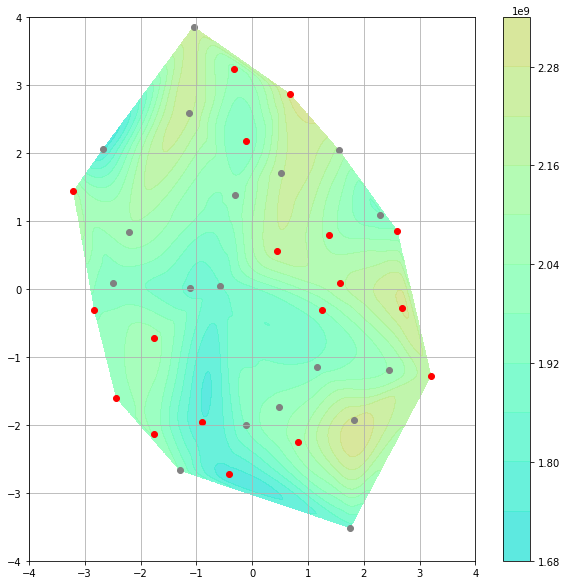

In [12]:
from scipy.interpolate import griddata
x = out3[:,0] 
y = out3[:,1]
z = reg.predict(AS.P)

# Convert from pandas dataframes to numpy arrays
X, Y, Z, = np.array([]), np.array([]), np.array([])
for i in range(len(x)):
        X = np.append(X, x[i])
        Y = np.append(Y, y[i])
        Z = np.append(Z, z[i])

# create x-y points to be used in heatmap
xi = np.linspace(X.min(), X.max(), 1000)
yi = np.linspace(Y.min(), Y.max(), 1000)

# Z is a matrix of x-y values
zi = griddata((X, Y), Z, (xi[None,:], yi[:,None]), method='cubic')

# I control the range of my colorbar by removing data 
# outside of my range of interest
zmin = 1.0*10**9
zmax = 3*10**9
zi[(zi<zmin) | (zi>zmax)] = None

# Create the contour plot
plt.figure(figsize=(10,10))
CS = plt.contourf(xi, yi, zi, 10, cmap=plt.cm.rainbow,
                  vmax=zmax, vmin=zmin, alpha=.8)
plt.colorbar()
plt.scatter(out3[:18, 0], out3[:18, 1], color='grey')
plt.scatter(out3[18:, 0], out3[18:, 1], color='r')
#ax = sns.kdeplot(out3[18:,0], out3[18:,1], shade=True)


plt.ylim([-4,4])
plt.xlim([-4,4])
plt.grid()